In [215]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [216]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [217]:
df = pd.read_csv("https://drive.google.com/uc?export=download&id=1f5nS06bwXj0plGiSBMJXmBoHJjmkIqs4")

df.head()

,Rank,City,PriceToIncomeRatio,GrossRentalYieldCityCentre,GrossRentalYieldOutsideOfCentre,PriceToRentRatioCityCentre,PriceToRentRatioOutsideOfCityCentre,MortgageAsAPercentageOfIncome,AffordabilityIndex
0,1,Saarbrucken,5.39,4.47,4.88,22.37,20.48,32.25,3.10
1,2,Essen,5.54,5.79,4.18,17.27,23.91,33.38,3.00
2,3,Dortmund,5.52,3.49,3.94,28.66,25.36,33.58,2.98
3,4,Mainz,6.19,4.42,4.06,22.64,24.65,36.80,2.72
4,5,Dresden,6.15,3.78,3.67,26.43,27.27,36.98,2.70


In [218]:
df.head(10)


,Rank,City,PriceToIncomeRatio,GrossRentalYieldCityCentre,GrossRentalYieldOutsideOfCentre,PriceToRentRatioCityCentre,PriceToRentRatioOutsideOfCityCentre,MortgageAsAPercentageOfIncome,AffordabilityIndex
0,1,Saarbrucken,5.39,4.47,4.88,22.37,20.48,32.25,3.10
1,2,Essen,5.54,5.79,4.18,17.27,23.91,33.38,3.00
2,3,Dortmund,5.52,3.49,3.94,28.66,25.36,33.58,2.98
3,4,Mainz,6.19,4.42,4.06,22.64,24.65,36.80,2.72
4,5,Dresden,6.15,3.78,3.67,26.43,27.27,36.98,2.70
5,6,Aachen,6.67,2.71,3.97,36.92,25.22,37.69,2.65
6,7,Erlangen,6.77,2.99,2.83,33.45,35.31,39.88,2.51
7,8,Mannheim,6.63,3.60,3.20,27.78,31.21,41.07,2.43
8,9,Bremen,7.28,3.95,4.21,25.33,23.76,44.95,2.22
9,10,Nuremberg,7.88,3.14,3.27,31.85,30.54,45.42,2.20


In [219]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 9 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Rank                                 26 non-null     int64  
 1   City                                 26 non-null     object 
 2   PriceToIncomeRatio                   26 non-null     float64
 3   GrossRentalYieldCityCentre           26 non-null     float64
 4   GrossRentalYieldOutsideOfCentre      26 non-null     float64
 5   PriceToRentRatioCityCentre           26 non-null     float64
 6   PriceToRentRatioOutsideOfCityCentre  26 non-null     float64
 7   MortgageAsAPercentageOfIncome        26 non-null     float64
 8   AffordabilityIndex                   26 non-null     float64
dtypes: float64(7), int64(1), object(1)
memory usage: 2.0+ KB


In [220]:
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

In [221]:
target = "PriceToIncomeRatio"

num_cols = df.select_dtypes(include=np.number).columns
num_cols = num_cols.drop(target, errors='ignore')


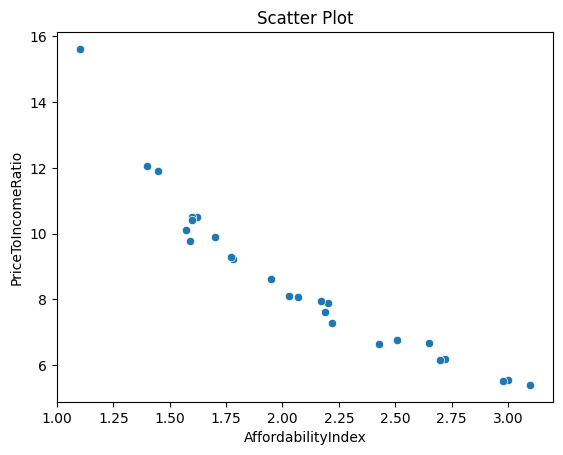

In [222]:
sns.scatterplot(x=df['AffordabilityIndex'], y=df[target])
plt.title("Scatter Plot")
plt.show()



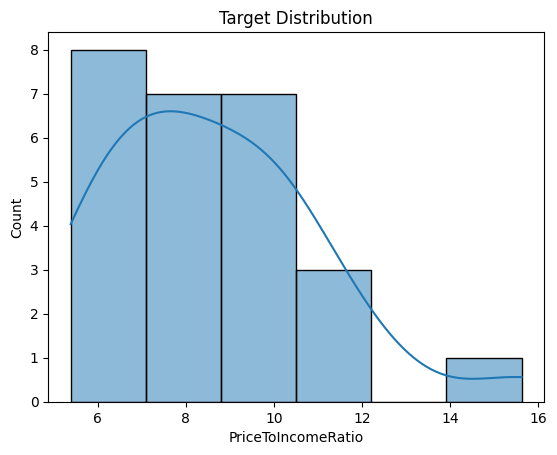

In [223]:
sns.histplot(df[target], kde=True)
plt.title("Target Distribution")
plt.show()

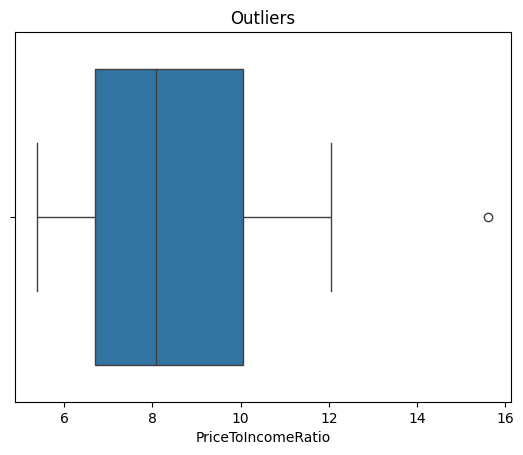

In [224]:
sns.boxplot(x=df[target])
plt.title("Outliers")
plt.show()

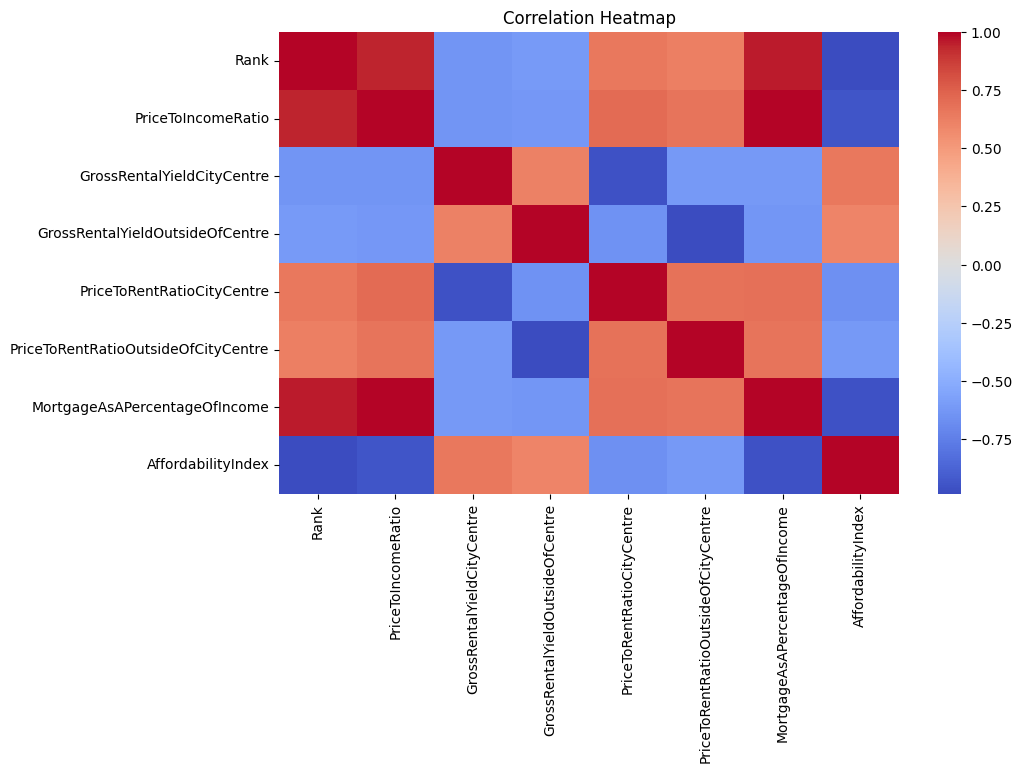

In [225]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [226]:

data = df.copy()

for col in num_cols:
    data[f"log_{col}"] = np.log1p(data[col])

for col in num_cols:
    data[f"{col}_sq"] = data[col] ** 2




In [227]:
X = data.drop(columns=[target])
y = data[target]

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [228]:
X_train = X_train.drop(columns=['City'], errors='ignore')
X_val = X_val.drop(columns=['City'], errors='ignore')
X_test = X_test.drop(columns=['City'], errors='ignore')

In [229]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_estimators=300, random_state=42)

In [230]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3
)

gb.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200)

In [231]:
from sklearn.metrics import r2_score, mean_absolute_error

val_rf = rf.predict(X_val)
val_gb = gb.predict(X_val)

print("RF R2:", r2_score(y_val, val_rf))
print("GB R2:", r2_score(y_val, val_gb))

RF R2: 0.9031571300034617
GB R2: 0.965492398188441


In [232]:
best_model = rf

best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

print("Test R2:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

Test R2: 0.8748774290767144
MAE: 0.39017500000000016


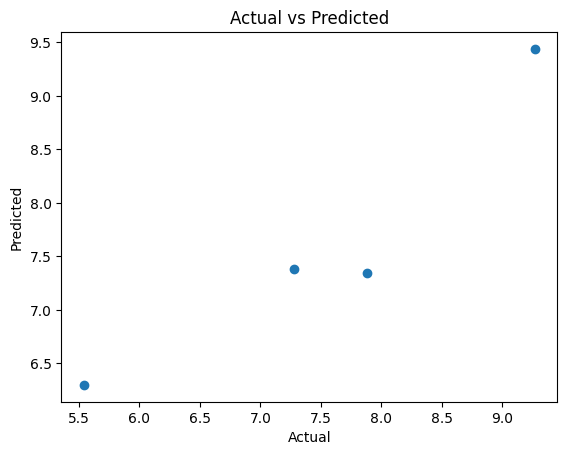

In [233]:
plt.scatter(y_test, pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()



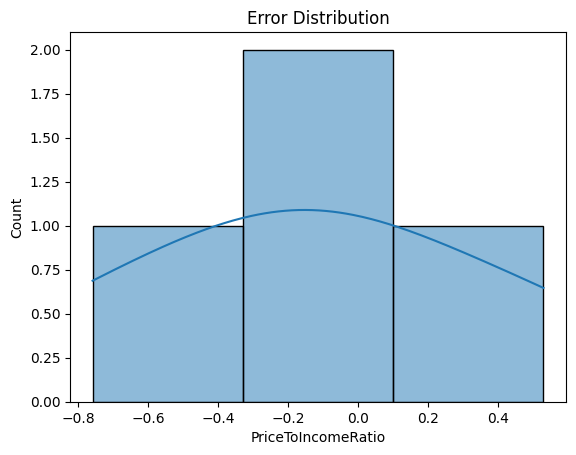

In [234]:
sns.histplot(y_test - pred, kde=True)
plt.title("Error Distribution")
plt.show()

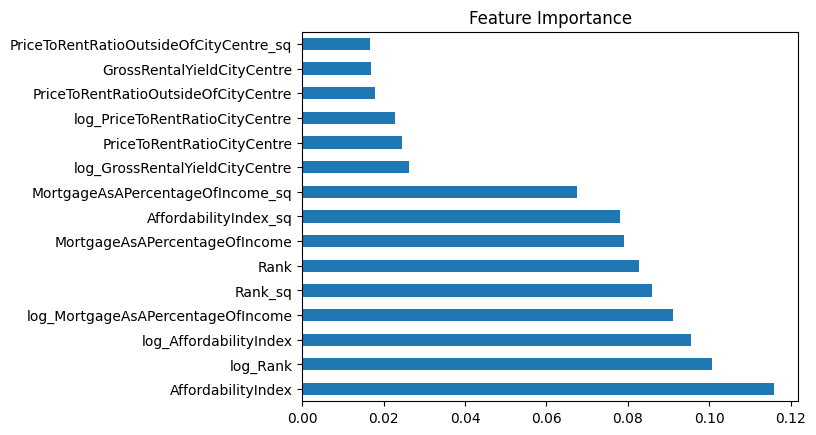

In [235]:
importances = best_model.feature_importances_

feat_imp = pd.Series(importances, index=X_train.columns)
feat_imp.sort_values(ascending=False).head(15).plot(kind='barh')

plt.title("Feature Importance")
plt.show()

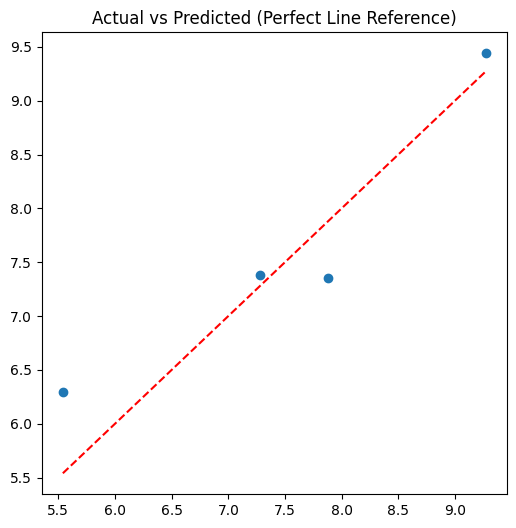

In [236]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.title("Actual vs Predicted (Perfect Line Reference)")
plt.show()

In [238]:
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
import numpy as np

print(" -----Enter Input Values----")

aff = widgets.FloatText(description="Affordability:")
gr1 = widgets.FloatText(description="Rent Yield C:")
gr2 = widgets.FloatText(description="Rent Yield O:")
pr1 = widgets.FloatText(description="Price-Rent C:")
pr2 = widgets.FloatText(description="Price-Rent O:")
mort = widgets.FloatText(description="Mortgage %:")
extra = widgets.FloatText(description="Extra:")


button = widgets.Button(description="Predict")
output = widgets.Output()

feature_columns = X_train.columns



def predict(b):
    with output:
        output.clear_output()

        try:

            features = [
                aff.value, gr1.value, gr2.value,
                pr1.value, pr2.value, mort.value,
                extra.value
            ]


            input_df = pd.DataFrame([features], columns=[
                'AffordabilityIndex',
                'RentYieldCityCentre',
                'RentYieldOutside',
                'PriceToRentRatioCityCentre',
                'PriceToRentRatioOutside',
                'MortgageAsAPercentageOfIncome',
                'ExtraFeature'
            ])

            for col in input_df.columns:
                input_df[f"log_{col}"] = np.log1p(input_df[col])
                input_df[f"{col}_sq"] = input_df[col] ** 2

            input_df = input_df.reindex(columns=feature_columns, fill_value=0)

            result = best_model.predict(input_df)[0]

            print("RESULT SUMMARY")
            print("-----------------------------")
            print(f"Predicted Value: {round(result, 2)}")

            if result < 4:
                print("Very Affordable City")
            elif result < 6:
                print("Moderately Affordable")
            elif result < 8:
                print("Expensive City")
            else:
                print("Very Expensive")

        except Exception as e:
            print("Error:", e)


button.on_click(predict)

display(aff, gr1, gr2, pr1, pr2, mort, extra, button, output)

 -----Enter Input Values----


FloatText(value=0.0, description='Affordability:')

FloatText(value=0.0, description='Rent Yield C:')

FloatText(value=0.0, description='Rent Yield O:')

FloatText(value=0.0, description='Price-Rent C:')

FloatText(value=0.0, description='Price-Rent O:')

FloatText(value=0.0, description='Mortgage %:')

FloatText(value=0.0, description='Extra:')

Button(description='Predict', style=ButtonStyle())

Output()



1.   input Example

Affordability: 3
Rent Yield C: 2
Rent Yield O: 1.5
Price-Rent C: 25
Price-Rent O: 30
Mortgage %: 8
Extra Feature: 9

Expected result: Expensive /  Very Expensive



2.   input Example

Affordability: 8
Rent Yield C: 6
Rent Yield O: 5
Price-Rent C: 8
Price-Rent O: 10
Mortgage %: 3
Extra Feature: 6



 Expected result: Very Affordable /  Moderately Affordable

